# Анализ датасета Amazon Bestselling Books
# 
# **Задача:** Предсказание рейтинга книг на основе их характеристик (регрессия)
# 
# **Цель:** Сравнить три модели: Линейная регрессия, SVR, Дерево решений

Линейная регрессия:

    Идея: Предполагает, что между признаками и целевой переменной существует линейная связь. Результат вычисляется как взвешенная сумма признаков (Цена = Вес1 * Количество_страниц + Вес2 * Год + ...).

SVR (Support Vector Regression):

    Идея: Это версия метода опорных векторов для регрессии. Она ищет функцию, которая отклоняется от реальных значений не более чем на заданную величину (эпсилон), стремясь при этом быть как можно более "плоской".

Дерево решений:

    Идея: Разбивает данные на группы, задавая последовательные вопросы (например, Amazon BSR < 5000?). В каждом "листе" (конечной группе) делается предсказание (например, средний рейтинг книг в этой группе).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.tree import export_text
import scipy
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

In [3]:
df = pd.read_csv('books.csv')

In [4]:
# Выводим первые 5 строк
print("ПЕРВЫЕ 5 СТРОК ДАННЫХ:")
print("="*50)
print(df.head())

ПЕРВЫЕ 5 СТРОК ДАННЫХ:
   Rank                       Title           Author     Category  \
0     1         The Let Them Theory      Mel Robbins  Non-Fiction   
1     2            The Dinner Party  Freida McFadden      Fiction   
2     3           Project Hail Mary        Andy Weir      Fiction   
3     4  The Correspondent: A Novel   Virginia Evans      Fiction   
4     5               Atomic Habits      James Clear  Non-Fiction   

                  Sub-Genre     Format  Price (USD)  Rating   Reviews  \
0                 Self-Help  Paperback        14.99     4.7   98000.0   
1    Psychological Thriller  Paperback        11.69     4.3    1800.0   
2           Science Fiction  Paperback        12.99     4.8  130000.0   
3          Literary Fiction  Hardcover        19.58     4.6   87363.0   
4  Self-Help / Productivity  Paperback        16.99     4.8  120000.0   

   Weeks on List             Publisher  Year Published               ISBN  \
0           52.0             Hay House        

In [5]:
# Общая информация о датафрейме
print("ИНФОРМАЦИЯ О ДАННЫХ:")
print("="*50)
print(df.info())

ИНФОРМАЦИЯ О ДАННЫХ:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            500 non-null    int64  
 1   Title           500 non-null    str    
 2   Author          500 non-null    str    
 3   Category        500 non-null    str    
 4   Sub-Genre       500 non-null    str    
 5   Format          500 non-null    str    
 6   Price (USD)     500 non-null    float64
 7   Rating          500 non-null    float64
 8   Reviews         500 non-null    float64
 9   Weeks on List   500 non-null    float64
 10  Publisher       500 non-null    str    
 11  Year Published  500 non-null    float64
 12  ISBN            500 non-null    str    
 13  Amazon BSR      500 non-null    float64
 14  Amazon URL      500 non-null    str    
dtypes: float64(6), int64(1), str(8)
memory usage: 105.4 KB
None


In [6]:
# Статистика для числовых столбцов
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print("="*50)
print(df.describe())

ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
             Rank  Price (USD)      Rating        Reviews  Weeks on List  \
count  500.000000   500.000000  500.000000     500.000000     500.000000   
mean   250.500000    16.828040    4.412200   12605.154000      25.106000   
std    144.481833     6.801869    0.255032   24759.378719      68.100294   
min      1.000000     4.230000    3.600000      85.000000       1.000000   
25%    125.750000    11.207500    4.200000    1952.750000       6.000000   
50%    250.500000    15.945000    4.400000    3893.000000      12.000000   
75%    375.250000    21.930000    4.600000   10986.500000      22.000000   
max    500.000000    34.090000    5.000000  220000.000000    1200.000000   

       Year Published   Amazon BSR  
count      500.000000   500.000000  
mean      2021.032000  3862.358000  
std          5.116183  2368.629814  
min       1965.000000    30.000000  
25%       2019.000000  1789.750000  
50%       2022.000000  3735.000000  
75%       2024.000000  5555.250

In [7]:
# Проверяем, есть ли пропущенные значения
print("ПРОВЕРКА НА ПРОПУСКИ:")
print("="*50)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "Пропусков нет!")

ПРОВЕРКА НА ПРОПУСКИ:
Пропусков нет!


In [8]:
# Смотрим уникальные значения в текстовых столбцах
print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:")
print("="*50)
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n📌 {col}:")
    print(f"   Уникальных значений: {df[col].nunique()}")
    print(f"   Топ-5 самых частых:")
    print(df[col].value_counts().head())

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:

📌 Title:
   Уникальных значений: 500
   Топ-5 самых частых:
Title
The Let Them Theory           1
The Dinner Party              1
Project Hail Mary             1
The Correspondent: A Novel    1
Atomic Habits                 1
Name: count, dtype: int64

📌 Author:
   Уникальных значений: 168
   Топ-5 самых частых:
Author
Taylor Jenkins Reid    8
Colleen Hoover         8
Matthew Stover         8
Daniel Kahneman        8
Ta-Nehisi Coates       7
Name: count, dtype: int64

📌 Category:
   Уникальных значений: 2
   Топ-5 самых частых:
Category
Fiction        254
Non-Fiction    246
Name: count, dtype: int64

📌 Sub-Genre:
   Уникальных значений: 48
   Топ-5 самых частых:
Sub-Genre
Science Fiction       21
Self-Help             18
Romantasy             18
Middle Grade          18
Historical Fiction    17
Name: count, dtype: int64

📌 Format:
   Уникальных значений: 5
   Топ-5 самых частых:
Format
Paperback         199
Hardcover         156
Kindle Edition     72
Audiobook

In [9]:
target_col = 'Rating'  # <--- МОЖЕТЕ ИЗМЕНИТЬ

print(f"🎯 Целевая переменная: {target_col}")
print(f"📊 Тип задачи: РЕГРЕССИЯ (предсказание числа)")

# Создаем копию данных для обработки
df_clean = df.copy()

# Если предсказываем рейтинг, удаляем строки с пропущенным рейтингом
if target_col == 'Rating':
    df_clean = df_clean.dropna(subset=['Rating'])
    print(f"   Удалено строк с пропущенным рейтингом: {len(df) - len(df_clean)}")

🎯 Целевая переменная: Rating
📊 Тип задачи: РЕГРЕССИЯ (предсказание числа)
   Удалено строк с пропущенным рейтингом: 0


In [10]:
# Отделяем признаки от целевой переменной
X = df_clean.drop(columns=[target_col])  # Все столбцы, кроме целевого
y = df_clean[target_col]  # Только целевой столбец

print(f"📋 Признаки (X): {X.shape[1]} столбцов")
print(f"   {list(X.columns)}")
print(f"\n🎯 Цель (y): {y.name}")
print(f"   Диапазон значений: от {y.min():.2f} до {y.max():.2f}")
print(f"   Среднее значение: {y.mean():.2f}")

📋 Признаки (X): 14 столбцов
   ['Rank', 'Title', 'Author', 'Category', 'Sub-Genre', 'Format', 'Price (USD)', 'Reviews', 'Weeks on List', 'Publisher', 'Year Published', 'ISBN', 'Amazon BSR', 'Amazon URL']

🎯 Цель (y): Rating
   Диапазон значений: от 3.60 до 5.00
   Среднее значение: 4.41


NameError: name 'target_3col' is not defined

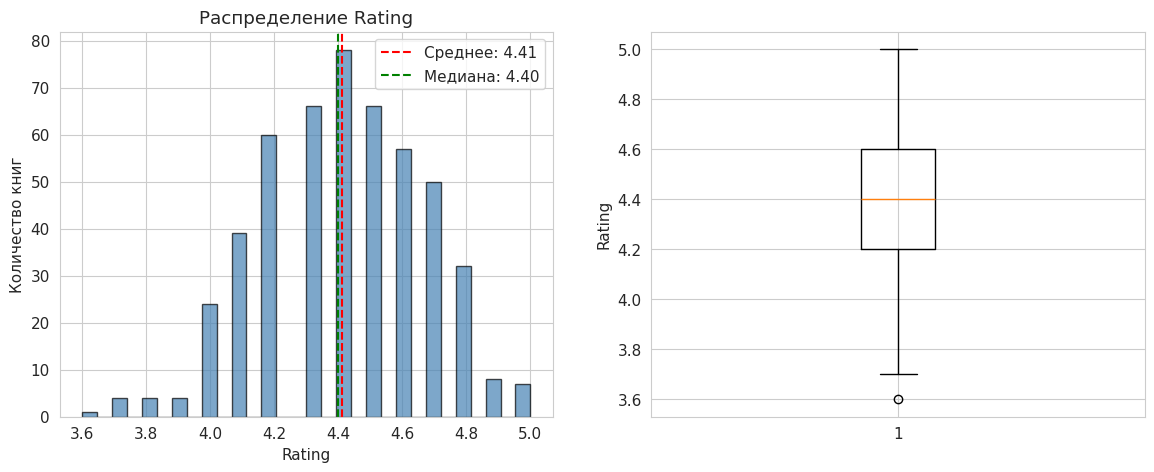

In [11]:
# Создаем графики для анализа целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Гистограмма распределения
axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel(target_col)
axes[0].set_ylabel('Количество книг')
axes[0].set_title(f'Распределение {target_col}')
axes[0].axvline(y.mean(), color='red', linestyle='--', 
                label=f'Среднее: {y.mean():.2f}')
axes[0].axvline(y.median(), color='green', linestyle='--', 
                label=f'Медиана: {y.median():.2f}')
axes[0].legend()

# График 2: Box plot (для выявления выбросов)
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel(target_col)
axes[1].set_title(f'Box plot {target_3col} (выбросы)')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Анализ целевой переменной', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Находим все текстовые столбцы
categorical_cols = X.select_dtypes(include=['object']).columns

print("🔄 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*50)

# Преобразуем текст в числа
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"✓ {col}: преобразован в числа")
    print(f"   Было {len(le.classes_)} уникальных значений → теперь числа от 0 до {len(le.classes_)-1}")

🔄 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
✓ Title: преобразован в числа
   Было 500 уникальных значений → теперь числа от 0 до 499
✓ Author: преобразован в числа
   Было 168 уникальных значений → теперь числа от 0 до 167
✓ Category: преобразован в числа
   Было 2 уникальных значений → теперь числа от 0 до 1
✓ Sub-Genre: преобразован в числа
   Было 48 уникальных значений → теперь числа от 0 до 47
✓ Format: преобразован в числа
   Было 5 уникальных значений → теперь числа от 0 до 4
✓ Publisher: преобразован в числа
   Было 56 уникальных значений → теперь числа от 0 до 55
✓ ISBN: преобразован в числа
   Было 500 уникальных значений → теперь числа от 0 до 499
✓ Amazon URL: преобразован в числа
   Было 1 уникальных значений → теперь числа от 0 до 0


In [ ]:
# Проверяем, остались ли пропуски
print("ПРОВЕРКА ПРОПУСКОВ ПОСЛЕ КОДИРОВАНИЯ:")
print("="*50)
print(X.isnull().sum())

# Если есть пропуски, заполняем их медианой
if X.isnull().sum().sum() > 0:
    print("\n⚠️ Обнаружены пропуски! Заполняем их...")
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    print("✓ Пропуски заполнены")
else:
    print("✓ Пропусков нет")

ПРОВЕРКА ПРОПУСКОВ ПОСЛЕ КОДИРОВАНИЯ:
Rank              0
Title             0
Author            0
Category          0
Sub-Genre         0
Format            0
Price (USD)       0
Reviews           0
Weeks on List     0
Publisher         0
Year Published    0
ISBN              0
Amazon BSR        0
Amazon URL        0
dtype: int64
✓ Пропусков нет


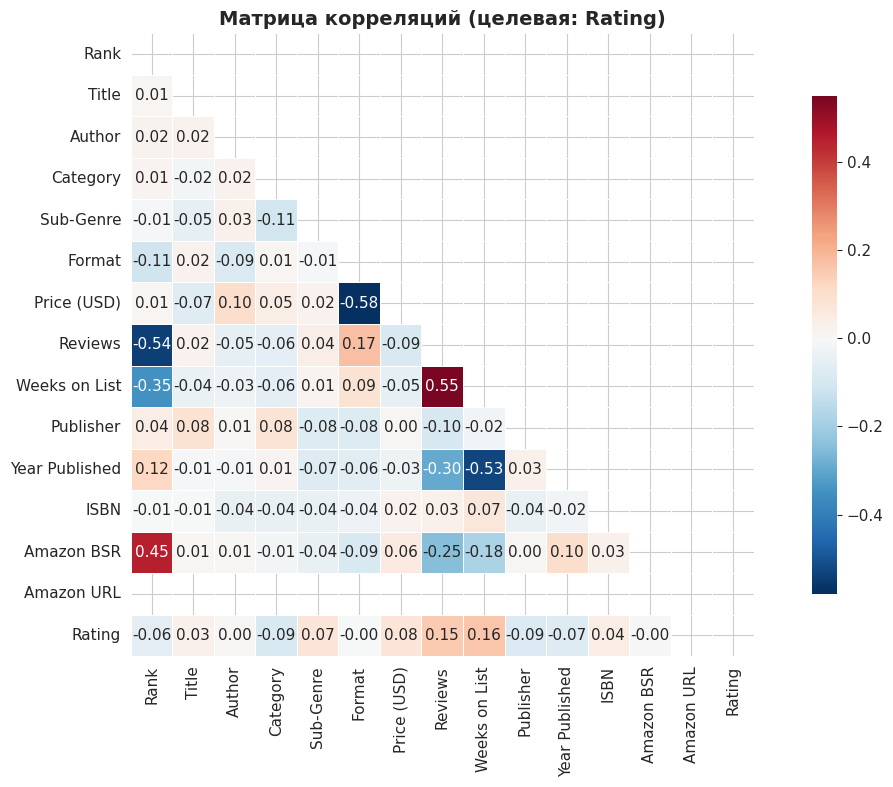


📈 КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
  Weeks on List       : +0.1608 (положительная, слабая)
  Reviews             : +0.1500 (положительная, слабая)
  Price (USD)         : +0.0760 (положительная, слабая)
  Sub-Genre           : +0.0735 (положительная, слабая)
  ISBN                : +0.0432 (положительная, слабая)
  Title               : +0.0312 (положительная, слабая)
  Author              : +0.0048 (положительная, слабая)
  Amazon BSR          : -0.0005 (отрицательная, слабая)
  Format              : -0.0041 (отрицательная, слабая)
  Rank                : -0.0628 (отрицательная, слабая)
  Year Published      : -0.0728 (отрицательная, слабая)
  Publisher           : -0.0884 (отрицательная, слабая)
  Category            : -0.0942 (отрицательная, слабая)
  Amazon URL          : +nan (отрицательная, слабая)


In [ ]:
# Смотрим, какие признаки сильнее всего влияют на целевую переменную
corr_data = X.copy()
corr_data[target_col] = y

# Строим матрицу корреляций
plt.figure(figsize=(12, 8))
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title(f'Матрица корреляций (целевая: {target_col})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Выводим самую сильную корреляцию
correlations = X.corrwith(y).sort_values(ascending=False)
print("\n📈 КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
print("="*50)
for feat, corr in correlations.items():
    strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
    direction = "положительная" if corr > 0 else "отрицательная"
    print(f"  {feat:<20}: {corr:+.4f} ({direction}, {strength})")

In [ ]:
# Масштабируем признаки (важно для линейной регрессии и SVR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns.tolist()

print("📏 МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
print("="*50)
print("Метод: StandardScaler (среднее=0, дисперсия=1)")
print(f"Количество признаков: {X_scaled.shape[1]}")
print("✓ Данные подготовлены для обучения")

# %% [markdown]
# ### Ячейка 15: Разделение на обучающую и тестовую выборки

# %%
# Делим данные: 80% на обучение, 20% на тестирование
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42  # random_state для воспроизводимости
)

print("🔄 РАЗДЕЛЕНИЕ ВЫБОРКИ")
print("="*50)
print(f"Обучающая выборка: {X_train.shape[0]} книг ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Тестовая выборка:   {X_test.shape[0]} книг ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

📏 МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
Метод: StandardScaler (среднее=0, дисперсия=1)
Количество признаков: 14
✓ Данные подготовлены для обучения
🔄 РАЗДЕЛЕНИЕ ВЫБОРКИ
Обучающая выборка: 400 книг (80.0%)
Тестовая выборка:   100 книг (20.0%)


In [ ]:
# %%
print("="*60)
print("🤖 МОДЕЛЬ 1: ЛИНЕЙНАЯ РЕГРЕССИЯ")
print("="*60)

# Создаем и обучаем модель
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Делаем предсказания на тестовой выборке
y_pred_lr = model_lr.predict(X_test)

print("✓ Модель обучена")
print(f"  Коэффициенты модели: {model_lr.coef_.shape[0]} шт.")
print(f"  Свободный член (intercept): {model_lr.intercept_:.4f}")

🤖 МОДЕЛЬ 1: ЛИНЕЙНАЯ РЕГРЕССИЯ
✓ Модель обучена
  Коэффициенты модели: 14 шт.
  Свободный член (intercept): 4.4163


In [ ]:
# %%
print("="*60)
print("🤖 МОДЕЛЬ 2: SVR (Support Vector Regression)")
print("="*60)

# Создаем и обучаем модель SVR
model_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model_svr.fit(X_train, y_train)

# Делаем предсказания
y_pred_svr = model_svr.predict(X_test)

print("✓ Модель обучена")
print("  Параметры: kernel='rbf', C=1.0, epsilon=0.1")

🤖 МОДЕЛЬ 2: SVR (Support Vector Regression)
✓ Модель обучена
  Параметры: kernel='rbf', C=1.0, epsilon=0.1


In [ ]:
# %%
print("="*60)
print("🤖 МОДЕЛЬ 3: ДЕРЕВО РЕШЕНИЙ")
print("="*60)

# Создаем и обучаем дерево решений
model_dt = DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_split=10)
model_dt.fit(X_train, y_train)

# Делаем предсказания
y_pred_dt = model_dt.predict(X_test)

print("✓ Модель обучена")
print("  Параметры: max_depth=5, min_samples_split=10")

🤖 МОДЕЛЬ 3: ДЕРЕВО РЕШЕНИЙ
✓ Модель обучена
  Параметры: max_depth=5, min_samples_split=10


In [ ]:
# Функция для расчета метрик
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n📊 {model_name}")
    print("-" * 40)
    print(f"  MSE  (среднеквадрат. ошибка): {mse:.4f}")
    print(f"  RMSE (корень из MSE):        {rmse:.4f}")
    print(f"  MAE  (ср. абс. ошибка):      {mae:.4f}")
    print(f"  R²   (качество модели):      {r2:.4f}")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Оцениваем все три модели
print("ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ")
print("="*60)

results_lr = evaluate_model(y_test, y_pred_lr, "Линейная регрессия")
results_svr = evaluate_model(y_test, y_pred_svr, "SVR")
results_dt = evaluate_model(y_test, y_pred_dt, "Дерево решений")

ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ

📊 Линейная регрессия
----------------------------------------
  MSE  (среднеквадрат. ошибка): 0.0664
  RMSE (корень из MSE):        0.2577
  MAE  (ср. абс. ошибка):      0.2018
  R²   (качество модели):      -0.0382

📊 SVR
----------------------------------------
  MSE  (среднеквадрат. ошибка): 0.0861
  RMSE (корень из MSE):        0.2935
  MAE  (ср. абс. ошибка):      0.2426
  R²   (качество модели):      -0.3465

📊 Дерево решений
----------------------------------------
  MSE  (среднеквадрат. ошибка): 0.0870
  RMSE (корень из MSE):        0.2949
  MAE  (ср. абс. ошибка):      0.2275
  R²   (качество модели):      -0.3600


In [ ]:
# Собираем все результаты в таблицу
results_df = pd.DataFrame({
    'Линейная регрессия': results_lr,
    'SVR': results_svr,
    'Дерево решений': results_dt
}).T

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("="*60)
print(results_df.round(4))

# Находим лучшую модель по R²
best_model = results_df['R²'].idxmax()
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model}")
print(f"   R² = {results_df.loc[best_model, 'R²']:.4f}")

СРАВНИТЕЛЬНАЯ ТАБЛИЦА
                       MSE    RMSE     MAE      R²
Линейная регрессия  0.0664  0.2577  0.2018 -0.0382
SVR                 0.0861  0.2935  0.2426 -0.3465
Дерево решений      0.0870  0.2949  0.2275 -0.3600

🏆 ЛУЧШАЯ МОДЕЛЬ: Линейная регрессия
   R² = -0.0382


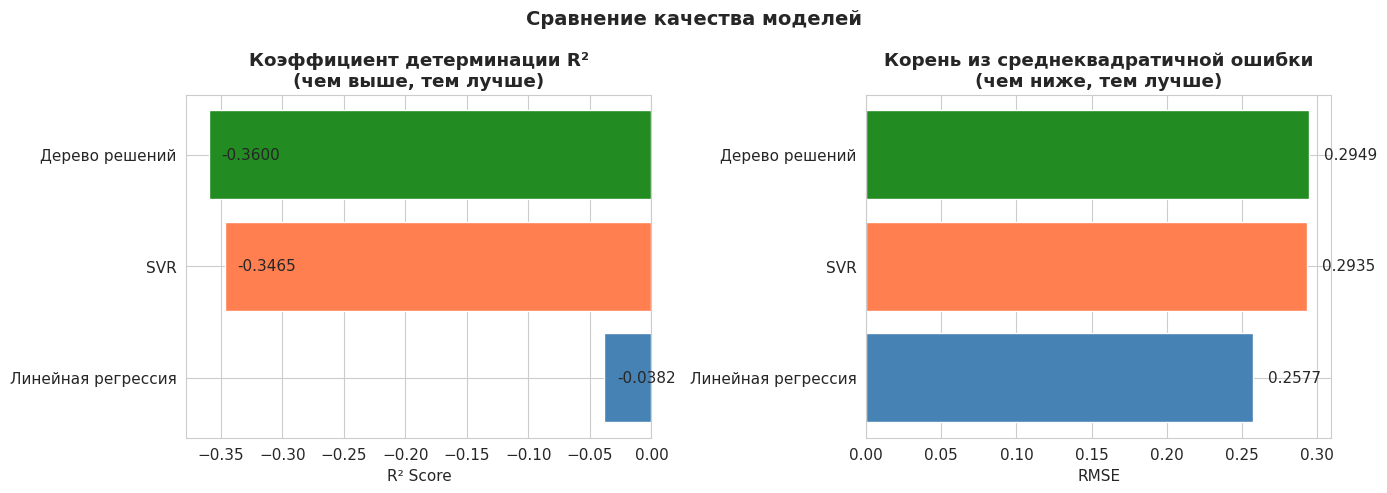

In [ ]:
# График сравнения метрик
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: R² (чем выше, тем лучше)
colors = ['steelblue', 'coral', 'forestgreen']
axes[0].barh(results_df.index, results_df['R²'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Коэффициент детерминации R²\n(чем выше, тем лучше)', fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Добавляем значения на график
for i, (model, r2) in enumerate(zip(results_df.index, results_df['R²'])):
    axes[0].text(r2 + 0.01, i, f'{r2:.4f}', va='center')

# График 2: RMSE (чем ниже, тем лучше)
axes[1].barh(results_df.index, results_df['RMSE'], color=colors)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Корень из среднеквадратичной ошибки\n(чем ниже, тем лучше)', fontweight='bold')

# Добавляем значения
for i, (model, rmse) in enumerate(zip(results_df.index, results_df['RMSE'])):
    axes[1].text(rmse + 0.01, i, f'{rmse:.4f}', va='center')

plt.suptitle('Сравнение качества моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

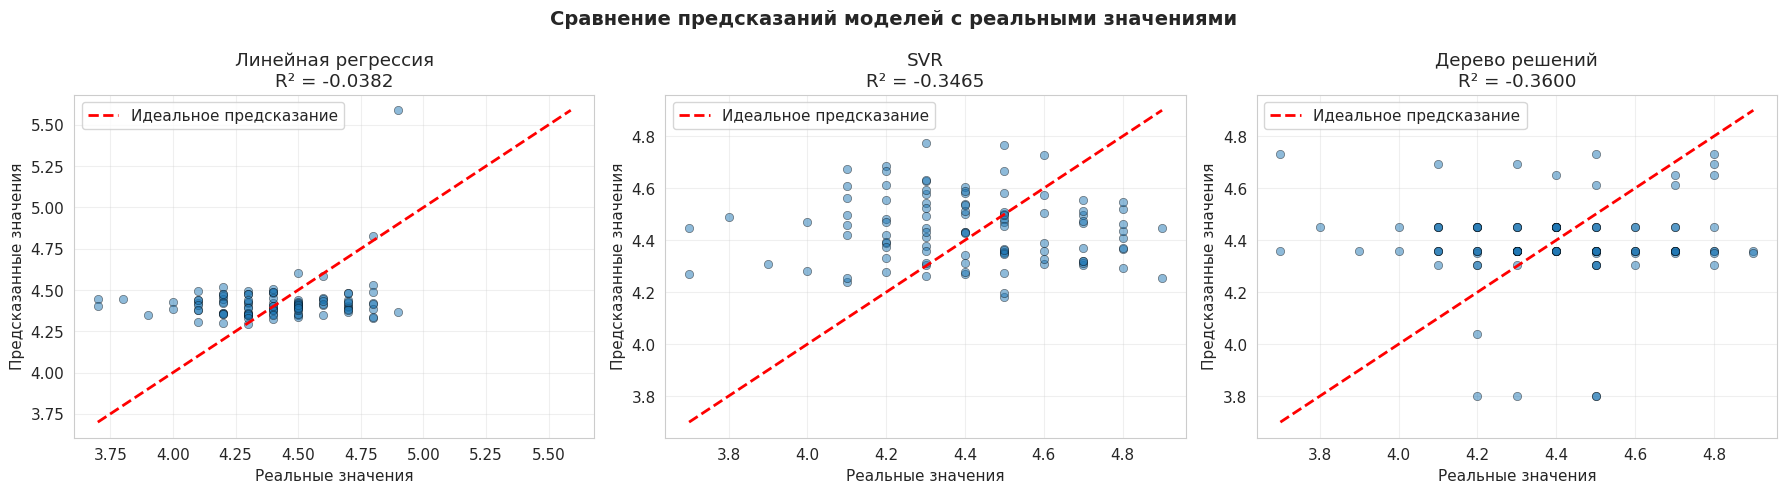

In [ ]:
# Сравниваем, насколько точно модели предсказывают
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Данные для графиков
predictions = {
    'Линейная регрессия': y_pred_lr,
    'SVR': y_pred_svr,
    'Дерево решений': y_pred_dt
}

for idx, (name, y_pred) in enumerate(predictions.items()):
    axes[idx].scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
    
    # Линия идеального предсказания
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 
                   'r--', lw=2, label='Идеальное предсказание')
    
    axes[idx].set_xlabel('Реальные значения', fontsize=11)
    axes[idx].set_ylabel('Предсказанные значения', fontsize=11)
    axes[idx].set_title(f'{name}\nR² = {results_df.loc[name, "R²"]:.4f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Сравнение предсказаний моделей с реальными значениями', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

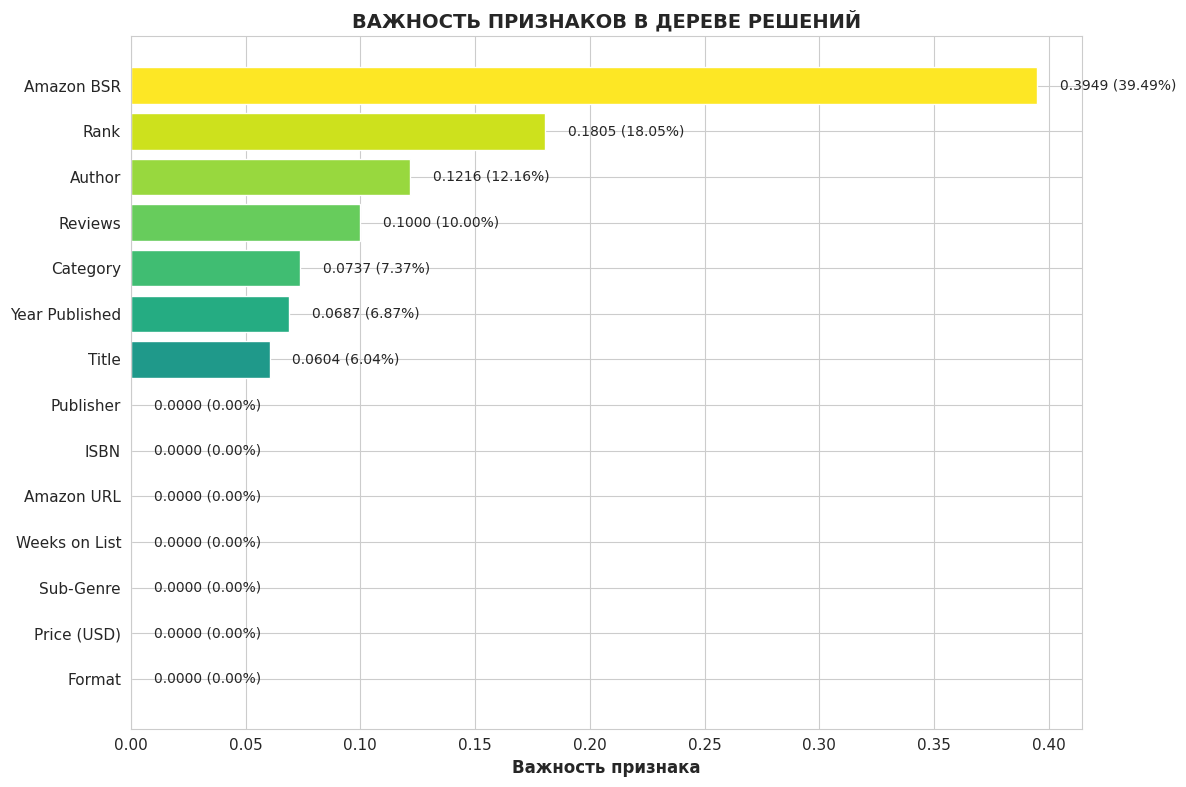


🔝 ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
1. Amazon BSR           → важность: 39.49%
2. Rank                 → важность: 18.05%
3. Author               → важность: 12.16%
4. Reviews              → важность: 10.00%
5. Category             → важность: 7.37%


In [ ]:
# Получаем важность каждого признака из дерева решений
feature_importance = model_dt.feature_importances_

# Сортируем по убыванию
indices = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importance = feature_importance[indices]

# Строим график
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_features)))[::-1]
bars = ax.barh(range(len(sorted_features)), sorted_importance, color=colors)

ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features)
ax.set_xlabel("Важность признака", fontsize=12, fontweight='bold')
ax.set_title("ВАЖНОСТЬ ПРИЗНАКОВ В ДЕРЕВЕ РЕШЕНИЙ", fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Добавляем проценты на график
for i, (bar, val) in enumerate(zip(bars, sorted_importance)):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f} ({val*100:.2f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Выводим топ-5 самых важных признаков
print("\n🔝 ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:")
print("="*50)
for i, (feat, imp) in enumerate(zip(sorted_features[:5], sorted_importance[:5])):
    print(f"{i+1}. {feat:<20} → важность: {imp*100:.2f}%")

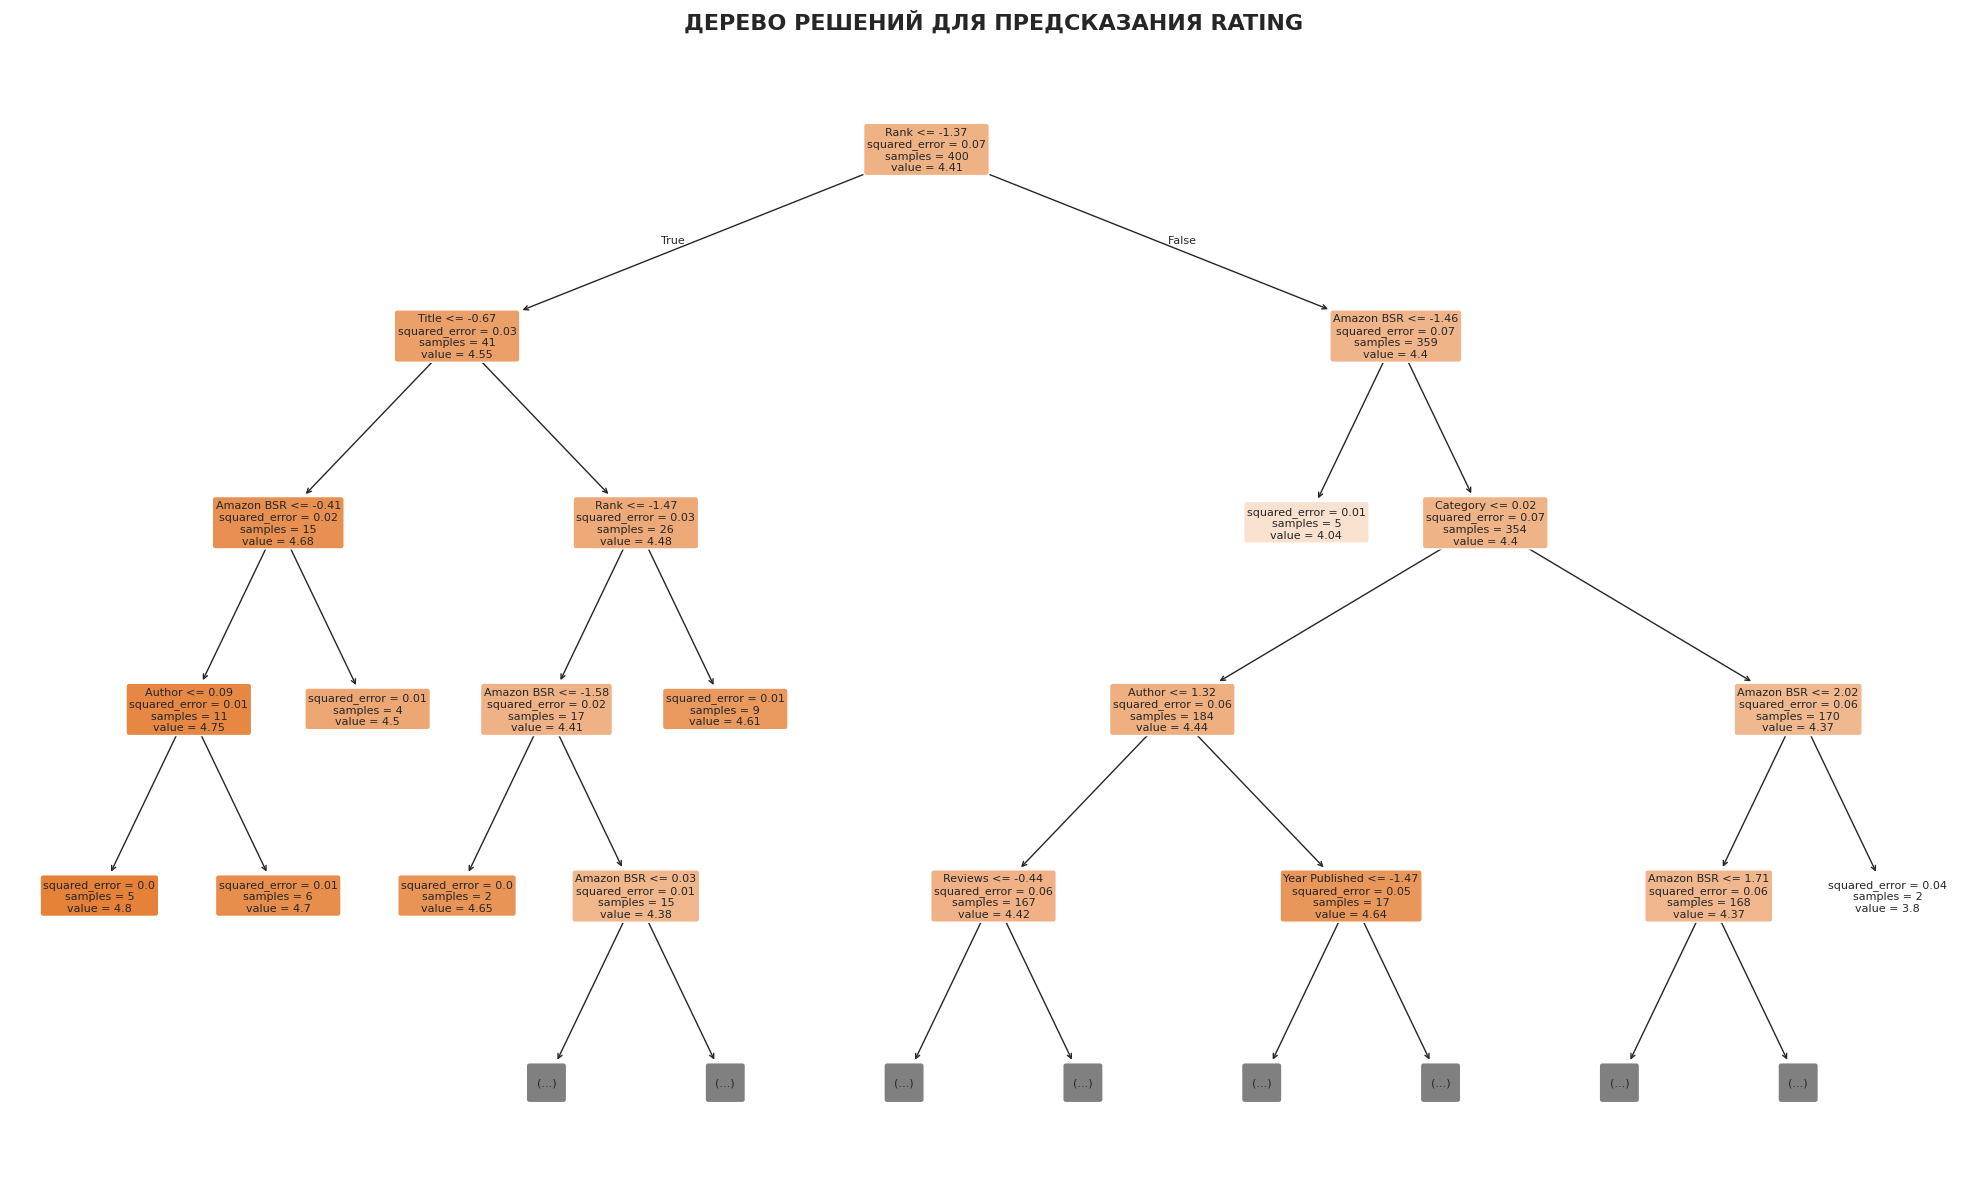

In [ ]:
# Рисуем дерево решений (ограничиваем глубину 4 уровнями для читаемости)
plt.figure(figsize=(20, 12))

plot_tree(
    model_dt,
    feature_names=feature_names,
    filled=True,           # Заливаем цветом
    rounded=True,          # Скругленные углы
    fontsize=8,            # Размер шрифта
    precision=2,           # Точность чисел
    max_depth=4            # Показываем только первые 4 уровня
)

plt.title(f"ДЕРЕВО РЕШЕНИЙ ДЛЯ ПРЕДСКАЗАНИЯ {target_col.upper()}", 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Экспортируем правила дерева в читаемый текстовый формат
tree_rules = export_text(
    model_dt,
    feature_names=feature_names,
    max_depth=5,           # Ограничиваем глубину
    spacing=3              # Отступы для читаемости
)

print("ПРАВИЛА ДЕРЕВА РЕШЕНИЙ (текстовое представление)")
print("="*70)
print(tree_rules)

print("\n📖 Как читать правила:")
print("  - '|---' обозначает новое правило")
print("  - 'feature <= X' - условие")
print("  - 'value: Y' - предсказанное значение")
print("  - 'samples: Z' - количество объектов в узле")

ПРАВИЛА ДЕРЕВА РЕШЕНИЙ (текстовое представление)
|--- Rank <= -1.37
|   |--- Title <= -0.67
|   |   |--- Amazon BSR <= -0.41
|   |   |   |--- Author <= 0.09
|   |   |   |   |--- value: [4.80]
|   |   |   |--- Author >  0.09
|   |   |   |   |--- value: [4.70]
|   |   |--- Amazon BSR >  -0.41
|   |   |   |--- value: [4.50]
|   |--- Title >  -0.67
|   |   |--- Rank <= -1.47
|   |   |   |--- Amazon BSR <= -1.58
|   |   |   |   |--- value: [4.65]
|   |   |   |--- Amazon BSR >  -1.58
|   |   |   |   |--- Amazon BSR <= 0.03
|   |   |   |   |   |--- value: [4.35]
|   |   |   |   |--- Amazon BSR >  0.03
|   |   |   |   |   |--- value: [4.50]
|   |   |--- Rank >  -1.47
|   |   |   |--- value: [4.61]
|--- Rank >  -1.37
|   |--- Amazon BSR <= -1.46
|   |   |--- value: [4.04]
|   |--- Amazon BSR >  -1.46
|   |   |--- Category <= 0.02
|   |   |   |--- Author <= 1.32
|   |   |   |   |--- Reviews <= -0.44
|   |   |   |   |   |--- value: [4.30]
|   |   |   |   |--- Reviews >  -0.44
|   |   |   |   |   

🔍 АНАЛИЗ ОШИБОК ЛУЧШЕЙ МОДЕЛИ: Линейная регрессия


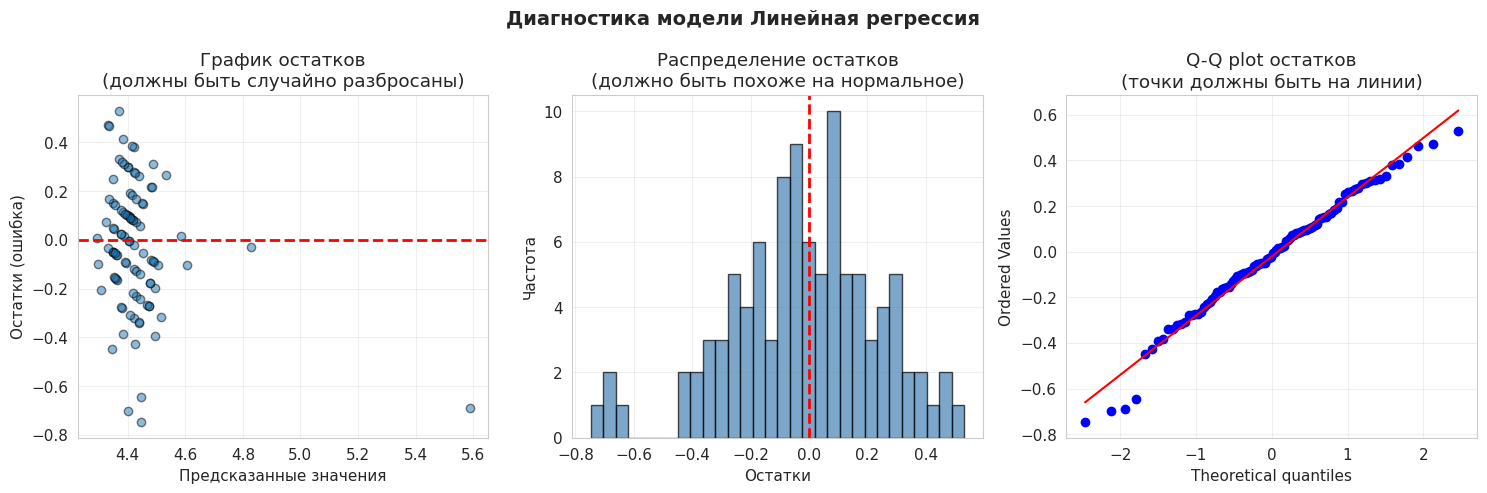


📊 СТАТИСТИКА ОСТАТКОВ:
  Среднее:           -0.0206 (должно быть близко к 0)
  Стандарт. отклон.: 0.2582
  Медиана:           -0.0135
  Асимметрия:        -0.4289 (0 = симметрично)


In [ ]:
# Находим лучшую модель (по R²) и анализируем ее ошибки
best_model_name = results_df['R²'].idxmax()
best_predictions = predictions[best_model_name]

# Рассчитываем остатки (разница между реальным и предсказанным)
residuals = y_test - best_predictions

print(f"🔍 АНАЛИЗ ОШИБОК ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print("="*60)

# Строим графики для анализа остатков
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Остатки vs предсказания
axes[0].scatter(best_predictions, residuals, alpha=0.5, edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Предсказанные значения')
axes[0].set_ylabel('Остатки (ошибка)')
axes[0].set_title('График остатков\n(должны быть случайно разбросаны)')
axes[0].grid(True, alpha=0.3)

# График 2: Гистограмма остатков
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Остатки')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков\n(должно быть похоже на нормальное)')
axes[1].grid(True, alpha=0.3)

# График 3: Q-Q plot (для проверки нормальности)
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot остатков\n(точки должны быть на линии)')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Диагностика модели {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Статистика остатков
print("\n📊 СТАТИСТИКА ОСТАТКОВ:")
print(f"  Среднее:           {residuals.mean():.4f} (должно быть близко к 0)")
print(f"  Стандарт. отклон.: {residuals.std():.4f}")
print(f"  Медиана:           {residuals.median():.4f}")
print(f"  Асимметрия:        {residuals.skew():.4f} (0 = симметрично)")

In [ ]:
# %%
print("="*70)
print("📊 ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ")
print("="*70)

print(f"""
1. 📚 ИНФОРМАЦИЯ О ДАТАСЕТЕ:
   ┌─ Всего книг: {len(df)} шт.
   ├─ Признаков: {len(feature_names)} шт.
   └─ Целевая переменная: {target_col}

2. 🤖 КАЧЕСТВО МОДЕЛЕЙ:
   ┌─ Линейная регрессия:  R² = {results_df.loc['Линейная регрессия', 'R²']:.4f}
   ├─ SVR:                R² = {results_df.loc['SVR', 'R²']:.4f}
   └─ Дерево решений:     R² = {results_df.loc['Дерево решений', 'R²']:.4f}

3. 🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}
   ├─ R² = {results_df.loc[best_model_name, 'R²']:.4f}
   └─ RMSE = {results_df.loc[best_model_name, 'RMSE']:.4f}

4. 🔑 ВАЖНЫЕ ПРИЗНАКИ (согласно дереву решений):
""")

for i, (feat, imp) in enumerate(zip(sorted_features[:3], sorted_importance[:3])):
    print(f"   {i+1}. {feat}: {imp*100:.2f}%")

print("""
5. 💡 РЕКОМЕНДАЦИИ:
   ├─ Для улучшения качества попробуйте ансамблевые методы (Random Forest)
   ├─ Проведите feature engineering (создание новых признаков)
   └─ Попробуйте другие гиперпараметры моделей

6. ⚠️ ВОЗМОЖНЫЕ ПРОБЛЕМЫ:
   ├─ Мало данных для обучения
   ├─ Выбросы в данных
   └─ Нелинейные зависимости, которые линейная модель не улавливает
""")

print("="*70)
print("✨ АНАЛИЗ ЗАВЕРШЕН ✨")
print("="*70)

📊 ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ

1. 📚 ИНФОРМАЦИЯ О ДАТАСЕТЕ:
   ┌─ Всего книг: 500 шт.
   ├─ Признаков: 14 шт.
   └─ Целевая переменная: Rating

2. 🤖 КАЧЕСТВО МОДЕЛЕЙ:
   ┌─ Линейная регрессия:  R² = -0.0382
   ├─ SVR:                R² = -0.3465
   └─ Дерево решений:     R² = -0.3600

3. 🏆 ЛУЧШАЯ МОДЕЛЬ: Линейная регрессия
   ├─ R² = -0.0382
   └─ RMSE = 0.2577

4. 🔑 ВАЖНЫЕ ПРИЗНАКИ (согласно дереву решений):

   1. Amazon BSR: 39.49%
   2. Rank: 18.05%
   3. Author: 12.16%

5. 💡 РЕКОМЕНДАЦИИ:
   ├─ Для улучшения качества попробуйте ансамблевые методы (Random Forest)
   ├─ Проведите feature engineering (создание новых признаков)
   └─ Попробуйте другие гиперпараметры моделей

6. ⚠️ ВОЗМОЖНЫЕ ПРОБЛЕМЫ:
   ├─ Мало данных для обучения
   ├─ Выбросы в данных
   └─ Нелинейные зависимости, которые линейная модель не улавливает

✨ АНАЛИЗ ЗАВЕРШЕН ✨
